# **Analiza i wizualizacja danych w Pythonie** #

**Importowanie bibliotek**

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.stats as stats

## **Etap 1: czyszczenie danych** ##

**Wczytanie danych z pliku csv**

In [3]:
df = pd.read_csv('apartments_rent_pl_2024_01.csv')
df.head(5)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
1,368e16142922433c709e6921a3b8f2a8,szczecin,blockOfFlats,70.0,3.0,7.0,11.0,1985.0,53.378485,14.657089,...,0.086,condominium,concreteSlab,premium,no,yes,yes,no,no,2900
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.0,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.338,condominium,concreteSlab,premium,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.7,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,0.096,condominium,concreteSlab,premium,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,NaN,56.2,3.0,1.0,4.0,NaN,53.441100,14.549100,...,0.050,condominium,NaN,NaN,no,no,NaN,no,no,3000


Wczytanie danych i wyświetlenie pierwszych 5 wierszy w celu wstępnego zapoznania z danymi.

**Informacje na temat struktury danych** 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8430 entries, 0 to 8429
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8430 non-null   str    
 1   city                  8430 non-null   str    
 2   type                  6227 non-null   str    
 3   squareMeters          8430 non-null   float64
 4   rooms                 8430 non-null   float64
 5   floor                 7400 non-null   float64
 6   floorCount            8259 non-null   float64
 7   buildYear             5938 non-null   float64
 8   latitude              8430 non-null   float64
 9   longitude             8430 non-null   float64
 10  centreDistance        8430 non-null   float64
 11  poiCount              8430 non-null   float64
 12  schoolDistance        8428 non-null   float64
 13  clinicDistance        8425 non-null   float64
 14  postOfficeDistance    8425 non-null   float64
 15  kindergartenDistance  8423 non-n


Analiza struktury danych wskazuje na konieczność uzupełnienia braków oraz poprawy typów zmiennych. Największe braki występują w kolumnach condition, buildingMaterial, buildYear i type. Zmienne określające odległość posiadają znikome luki. Zmienne binarne określające udogodnienia są zapisane jako tekst i powinny zostać zmienione. Z kolei zmienne takie jak liczba pokoi, piętro czy rok budowy są liczbami dziesiętnymi co jest spowodowane obecnością pustych wartości, jednak po procesie czyszczenia wymagają zamiany na liczby całkowite.

**Profilaktyczne usuwanie duplikatów**

In [5]:
df.drop_duplicates()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
1,368e16142922433c709e6921a3b8f2a8,szczecin,blockOfFlats,70.0,3.0,7.0,11.0,1985.0,53.378485,14.657089,...,0.086,condominium,concreteSlab,premium,no,yes,yes,no,no,2900
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.0,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.338,condominium,concreteSlab,premium,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.7,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,0.096,condominium,concreteSlab,premium,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,NaN,56.2,3.0,1.0,4.0,NaN,53.441100,14.549100,...,0.050,condominium,NaN,NaN,no,no,NaN,no,no,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8425,aeb9ea42eecfe32b2f791efe372a2e76,bydgoszcz,tenement,45.0,2.0,1.0,1.0,NaN,53.129551,18.029431,...,0.024,condominium,brick,NaN,no,no,NaN,no,no,2500
8426,4018cc5a9fd48bb2d66b84bc5e1b46ab,bydgoszcz,tenement,55.0,3.0,2.0,2.0,NaN,53.129551,18.029431,...,0.024,condominium,brick,NaN,no,no,no,no,no,3200
8427,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.0,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,no,no,no,no,2700
8428,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.0,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,yes,no,no,no,2800


**Identyfikacja brakujących danych** 

In [6]:
df.isna().sum()

id                         0
city                       0
type                    2203
squareMeters               0
rooms                      0
floor                   1030
floorCount               171
buildYear               2492
latitude                   0
longitude                  0
centreDistance             0
poiCount                   0
schoolDistance             2
clinicDistance             5
postOfficeDistance         5
kindergartenDistance       7
restaurantDistance        24
collegeDistance          104
pharmacyDistance          13
ownership                  0
buildingMaterial        3459
condition               6223
hasParkingSpace            0
hasBalcony                 0
hasElevator              454
hasSecurity                0
hasStorageRoom             0
price                      0
dtype: int64

Największy problem stanowi kolumna condition, która ma aż 6223 braków.

**Sprawdzenie wartości unikalnych** 

In [7]:
df['squareMeters'].unique()

array([52.  , 70.  , 43.  , ..., 54.35, 48.18, 25.58], shape=(1380,))

Wszystkie nazwy zostały sprawdzone po kolei i były poprawne.

**Wizualizacja struktury brakujących danych** 

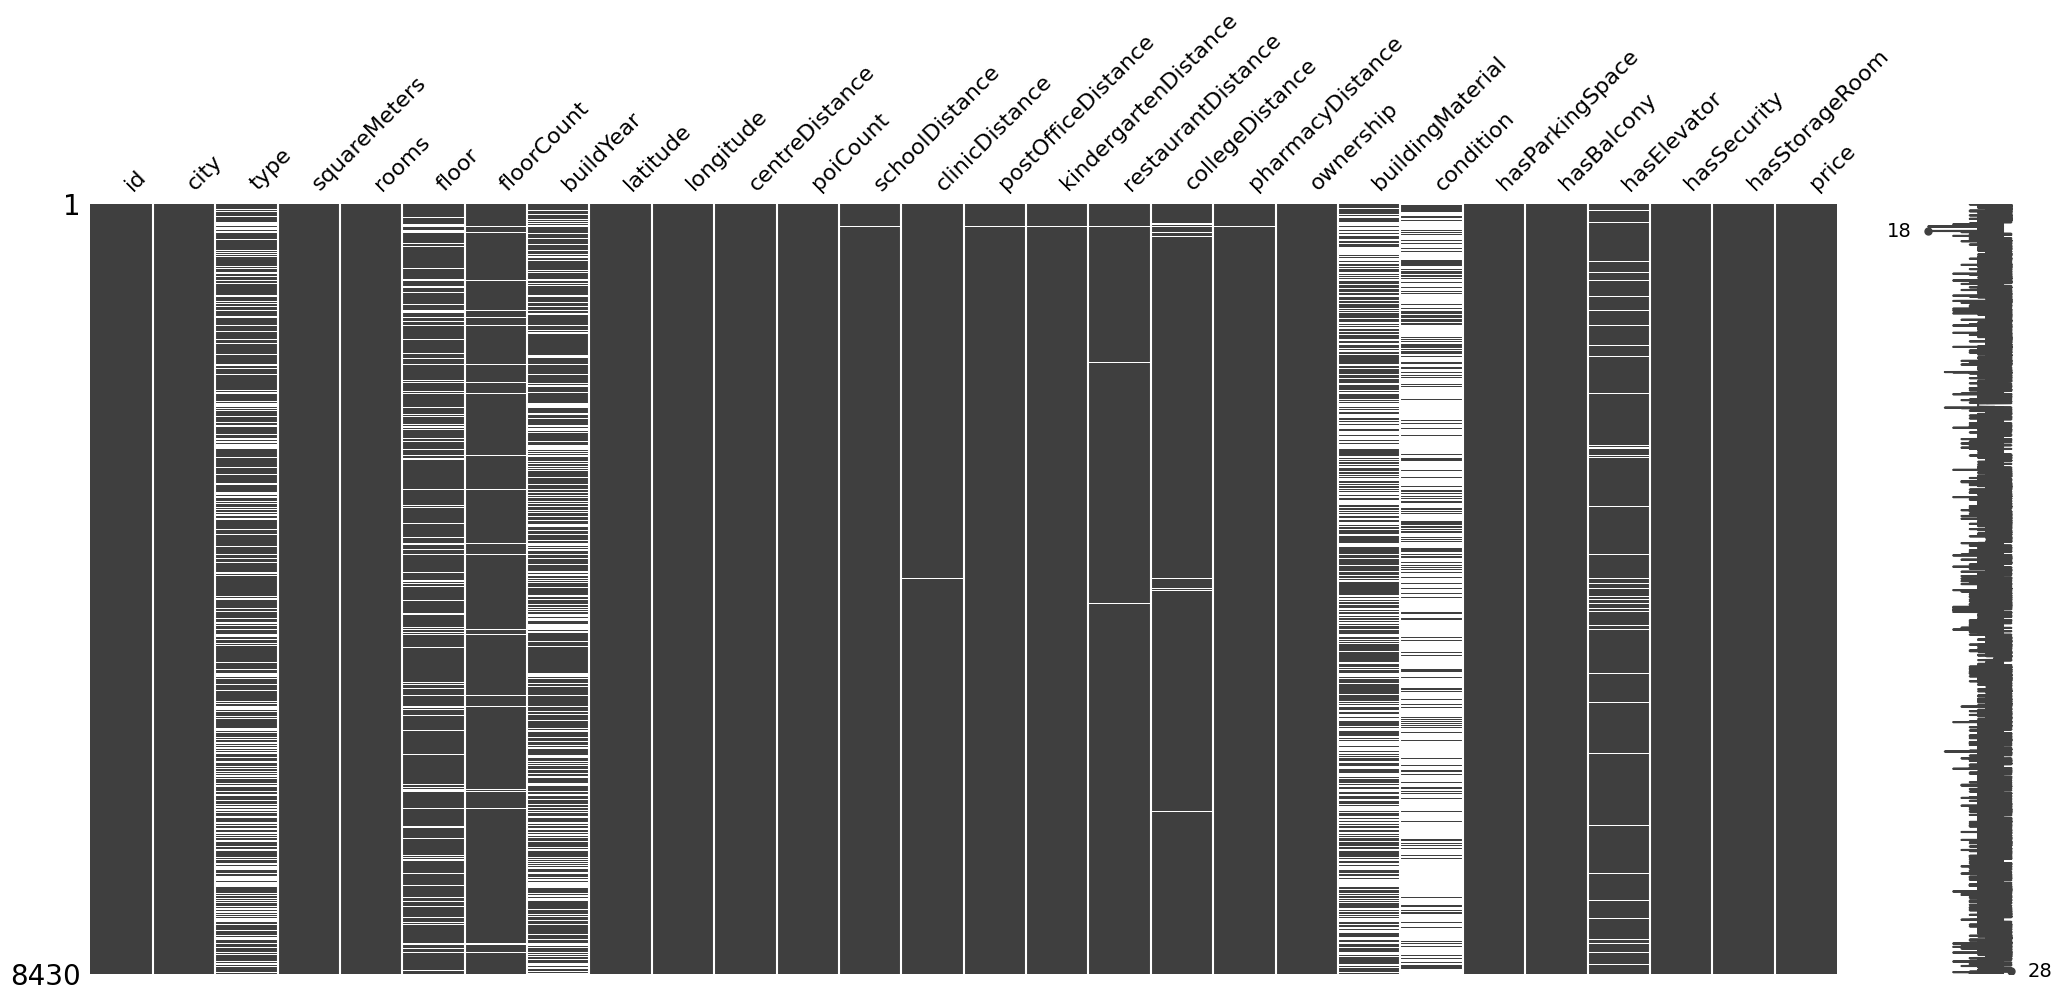

In [8]:
msno.matrix(df)
plt.show()

**Wizualizacja korelacji braków**

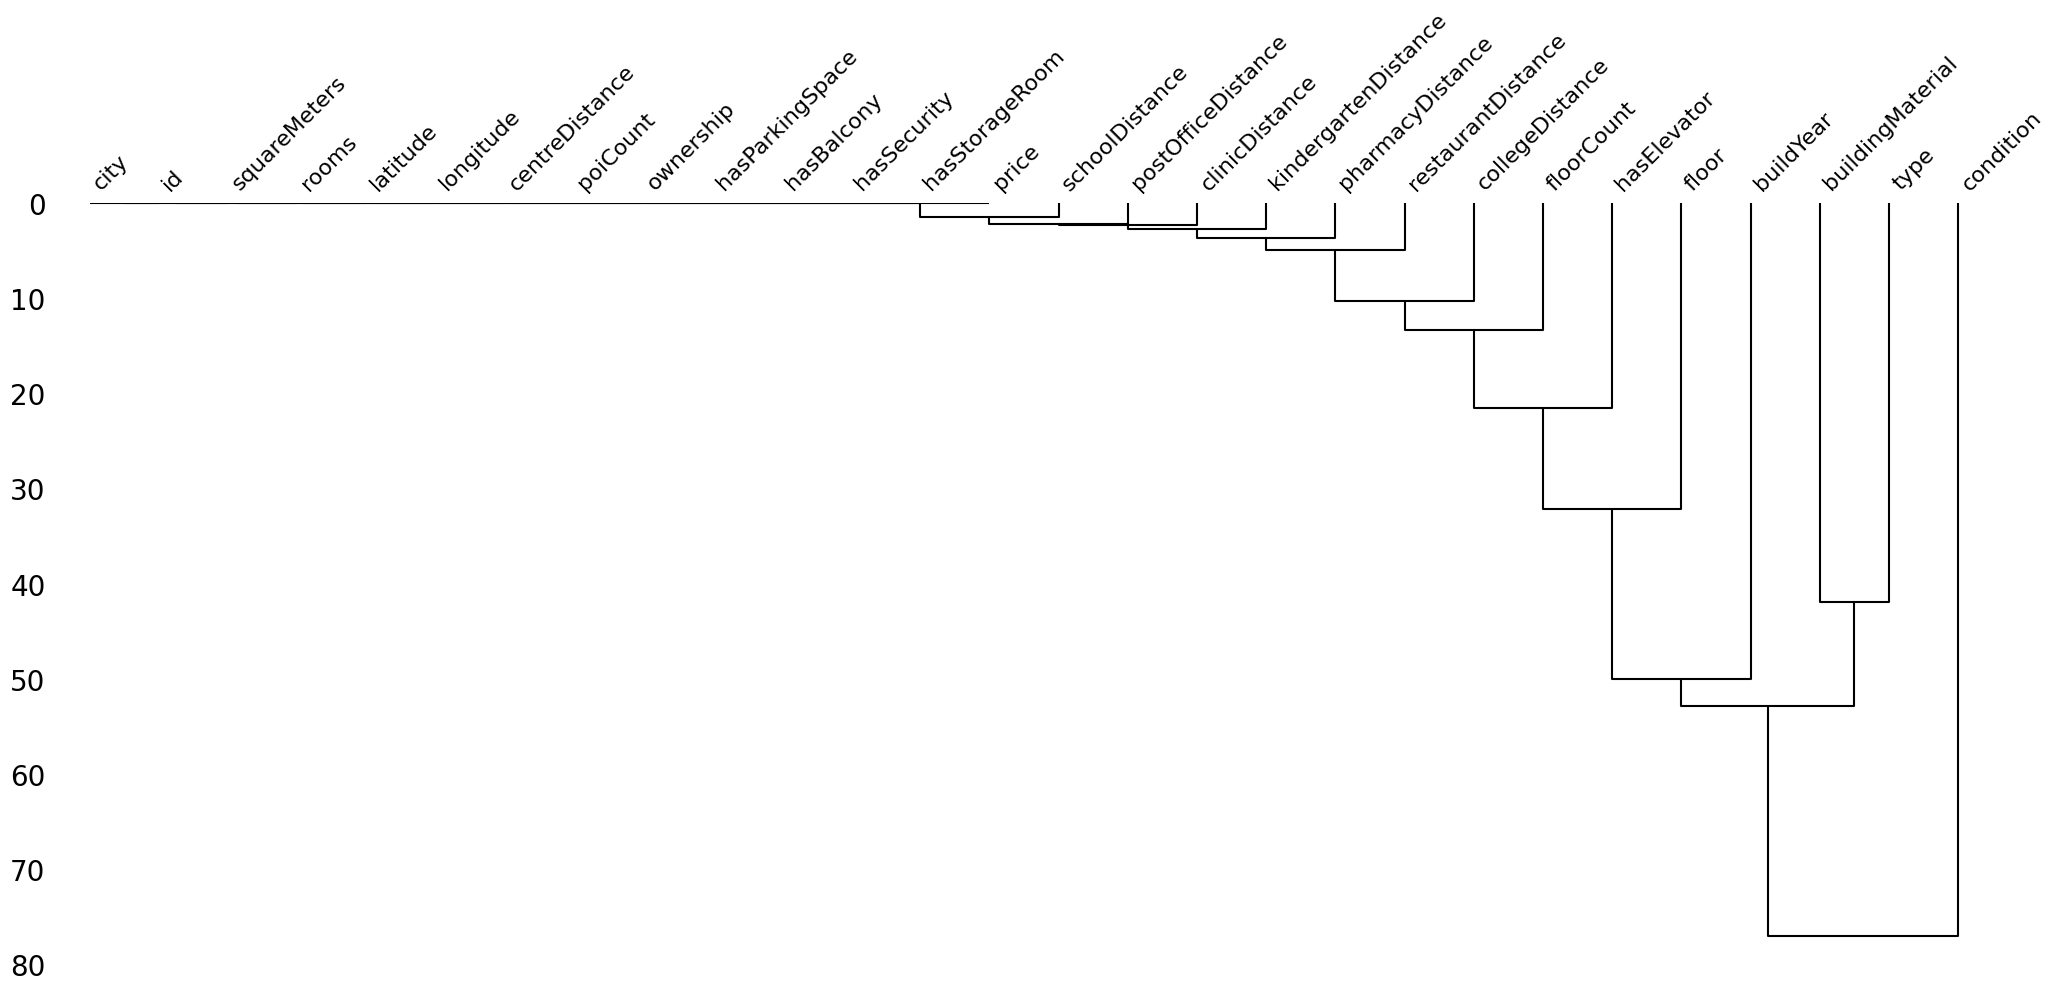

In [9]:
msno.dendrogram(df)
plt.show()

**Procentowy udział kompletnych danych**

<Axes: >

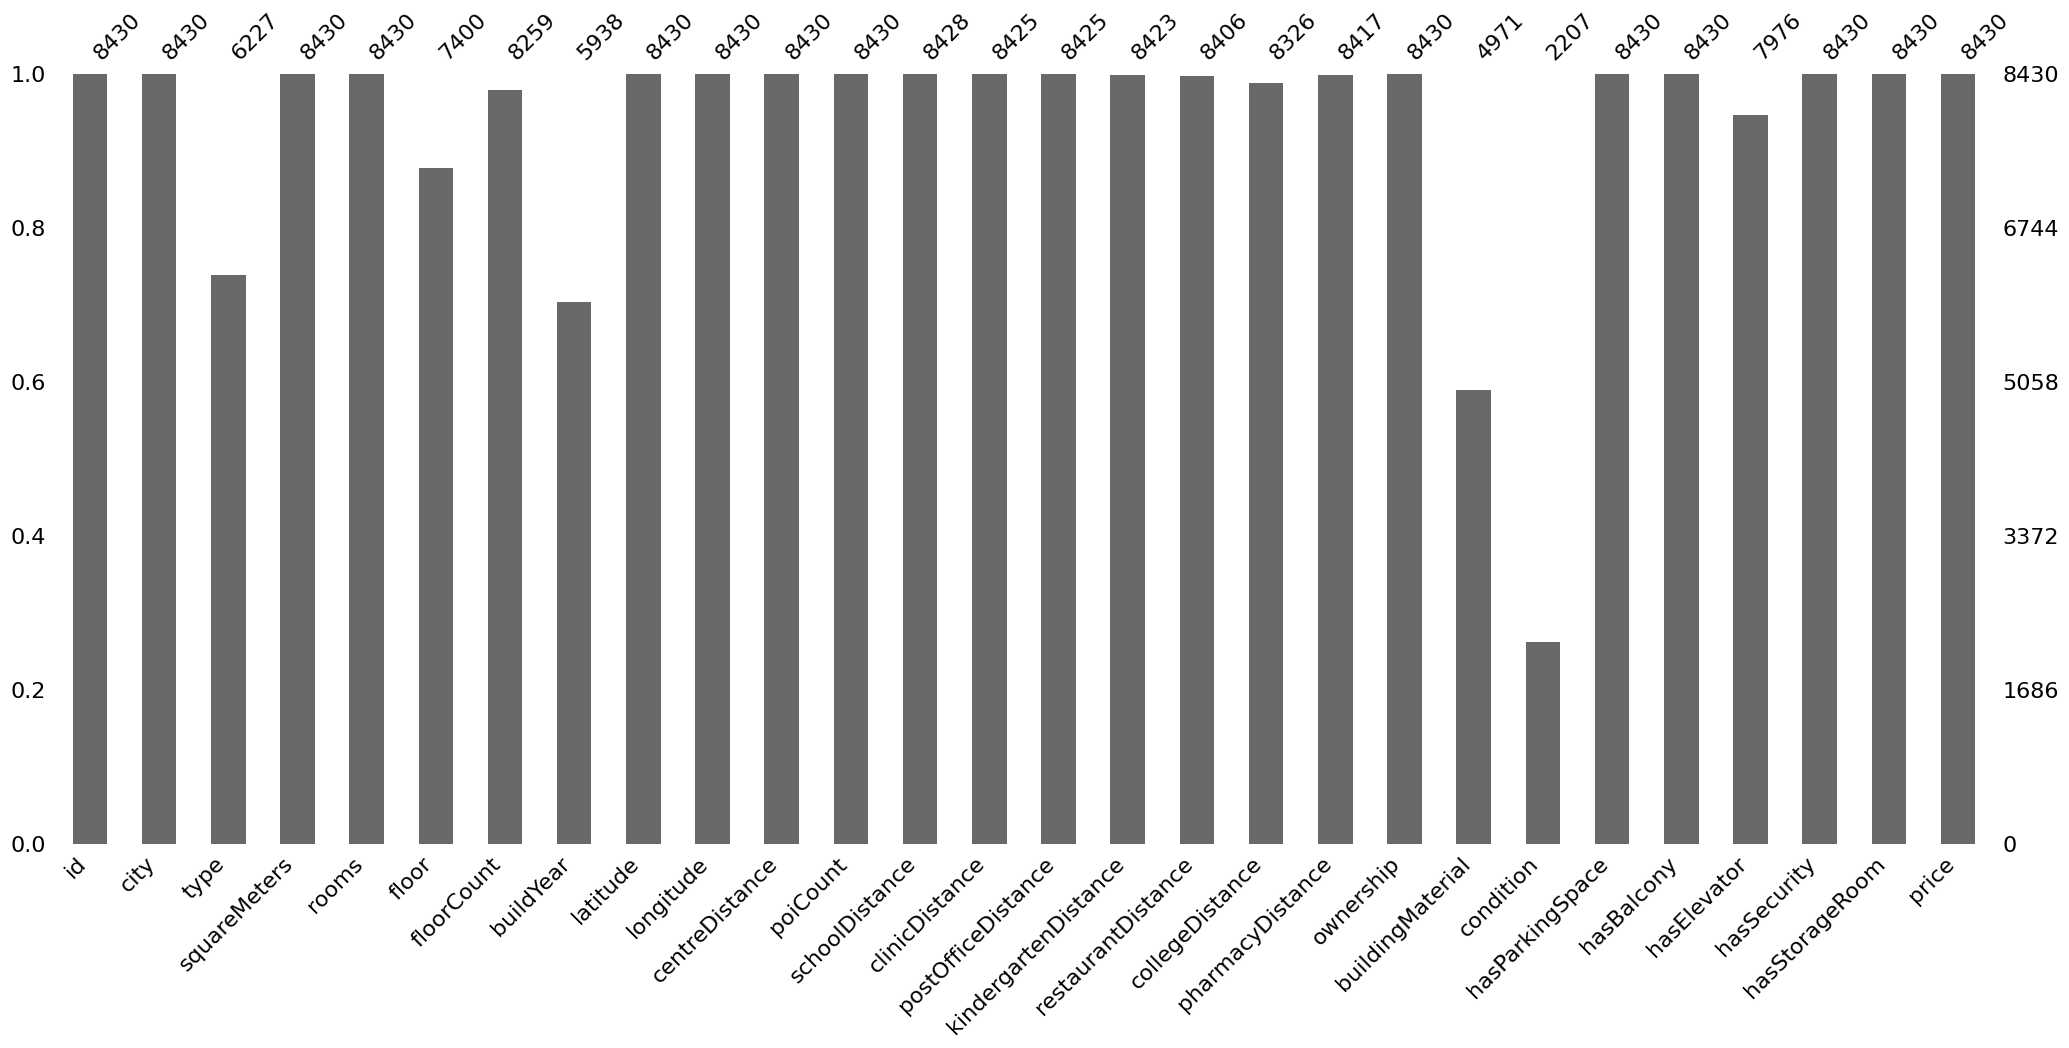

In [10]:
msno.bar(df)

**Uzupełnianie braków danych**

In [11]:
df['type'] = df['type'].fillna('unknown')
df['buildYear'] = df['buildYear'].fillna(0)
df['floor'] = df['floor'].fillna(-1)
df['buildingMaterial'] = df['buildingMaterial'].fillna('unknown')
df['hasElevator'] = df['hasElevator'].fillna('unknown')

df = df.drop(columns=['condition'])
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8430 entries, 0 to 8429
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8430 non-null   str    
 1   city                  8430 non-null   str    
 2   type                  8430 non-null   str    
 3   squareMeters          8430 non-null   float64
 4   rooms                 8430 non-null   float64
 5   floor                 8430 non-null   float64
 6   floorCount            8259 non-null   float64
 7   buildYear             8430 non-null   float64
 8   latitude              8430 non-null   float64
 9   longitude             8430 non-null   float64
 10  centreDistance        8430 non-null   float64
 11  poiCount              8430 non-null   float64
 12  schoolDistance        8428 non-null   float64
 13  clinicDistance        8425 non-null   float64
 14  postOfficeDistance    8425 non-null   float64
 15  kindergartenDistance  8423 non-n

Ze względu na dużą liczbę braków, usuwamy kolumnę condition z analizy.

**Usuwamy pojedyńcze wiersze ze względu na małą liczbę danych**

In [ ]:
df_braki = ['collegeDistance', 'pharmacyDistance', 'restaurantDistance', 'schoolDistance', 'postOfficeDistance','kindergartenDistance', 'clinicDistance','floorCount']
df_cleaned = df.dropna(subset=df_braki)
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 8122 entries, 0 to 8429
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8122 non-null   str    
 1   city                  8122 non-null   str    
 2   type                  8122 non-null   str    
 3   squareMeters          8122 non-null   float64
 4   rooms                 8122 non-null   float64
 5   floor                 8122 non-null   float64
 6   floorCount            8122 non-null   float64
 7   buildYear             8122 non-null   float64
 8   latitude              8122 non-null   float64
 9   longitude             8122 non-null   float64
 10  centreDistance        8122 non-null   float64
 11  poiCount              8122 non-null   float64
 12  schoolDistance        8122 non-null   float64
 13  clinicDistance        8122 non-null   float64
 14  postOfficeDistance    8122 non-null   float64
 15  kindergartenDistance  8122 non-null  

### **Zamiana typu danych** ###

Zamiana typu danych na int64

In [13]:
df_cleaned[['rooms', 'floor', 'floorCount','buildYear','poiCount']] = df_cleaned[['rooms', 'floor', 'floorCount','buildYear','poiCount']].astype('int64')

Zamiana typu danych na float64

In [14]:
df_cleaned[['price']] = df_cleaned[['price']].astype('float64')

Zamiana typu danych na string

In [15]:
df_cleaned[['id']] = df_cleaned[['id']].astype('str')

Zamiana typu danych na binarne

In [16]:
binarne = ['hasParkingSpace', 'hasBalcony', 'hasSecurity', 'hasStorageRoom']
df_cleaned[binarne] = df_cleaned[binarne].replace({'yes': 1, 'no': 0}).astype('int64')

## **Etap 2: wizualizacja danych** ##

**Wizualizacja z seaborn - histogram ceny mieszkań z logarytmiczną skalą**

<Axes: xlabel='price', ylabel='Count'>

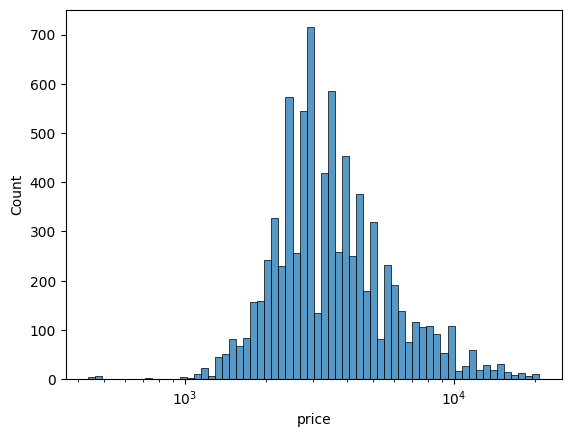

In [17]:
sns.histplot(data = df_cleaned, x = 'price', log_scale=True)

**Wizualizacja z seaborn - histogoram cen mieszkań w zależności od miasta**

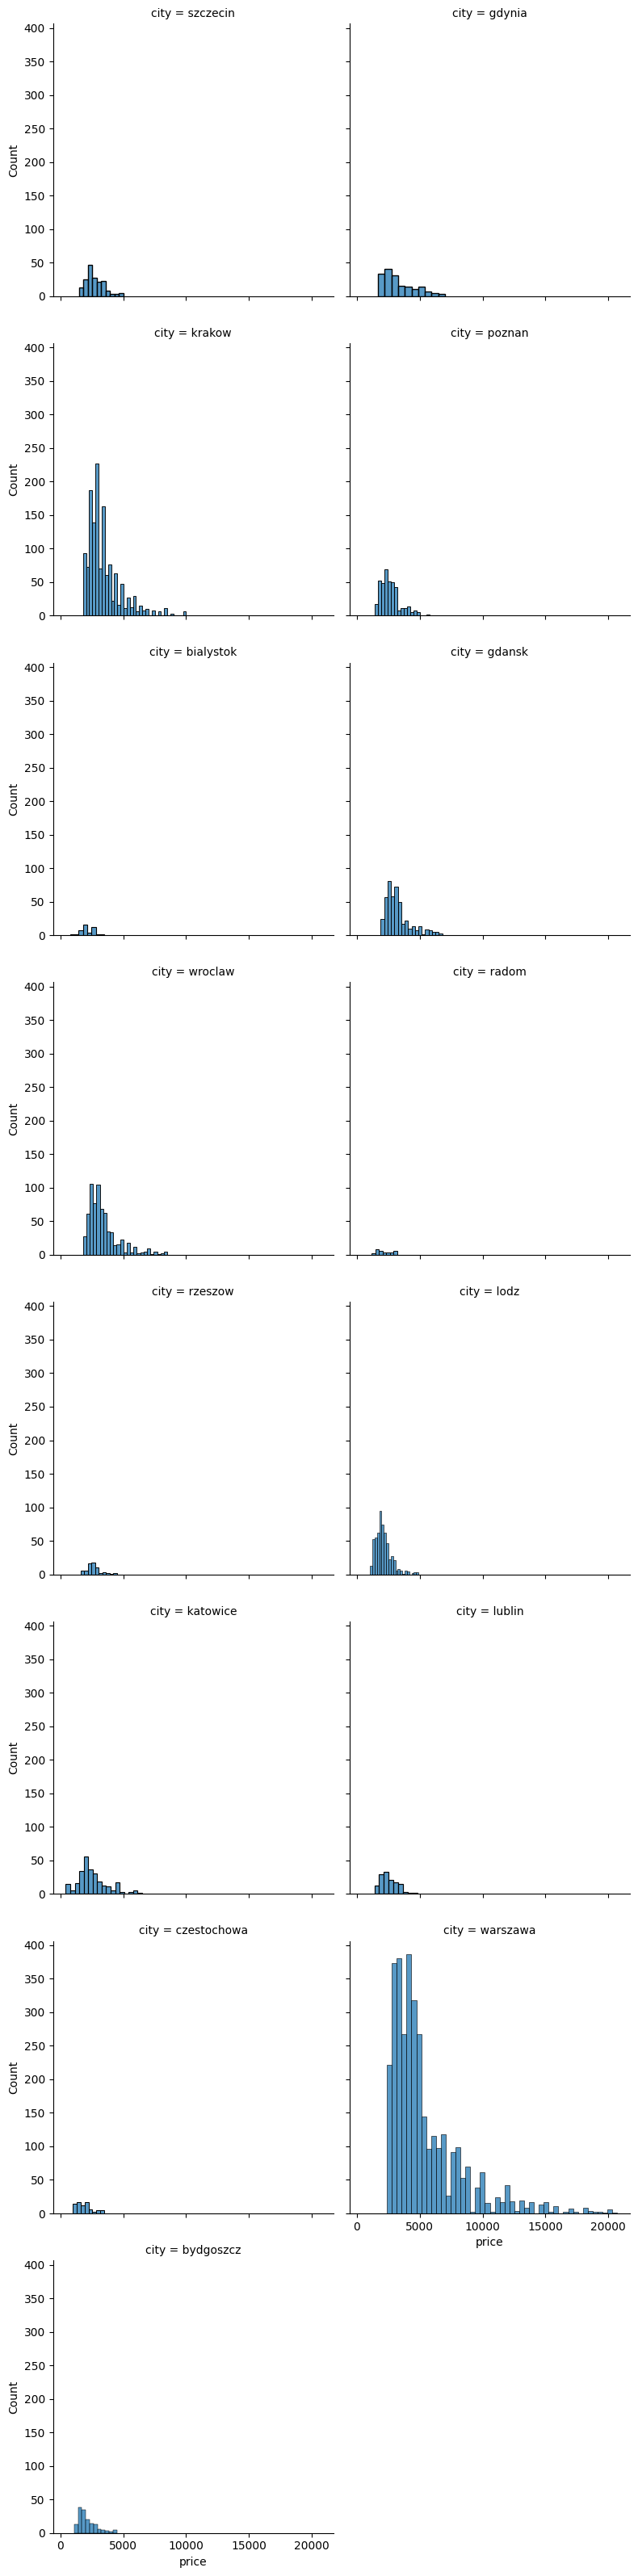

In [20]:
wykres = sns.FacetGrid(df_cleaned, col='city', col_wrap=2, height=4) 
wykres.map(sns.histplot, 'price') 

**Wizualizacja z seaborn - wykres punktowy cena vs m<sup>2</sup>**

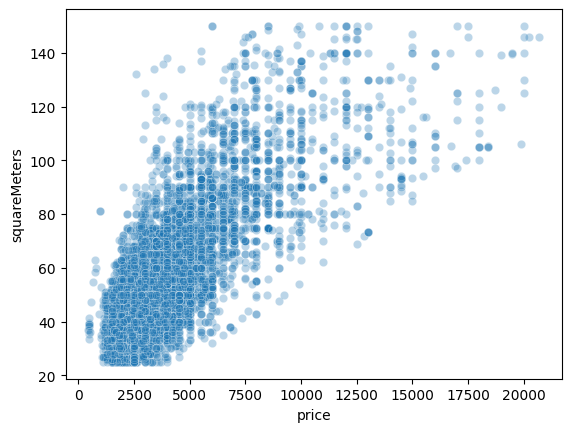

In [21]:
sns.scatterplot(data = df_cleaned, x = 'price', y = 'squareMeters', alpha = .3);

**Wizualizacja z plotly - wykres interaktywny cena vs m<sup>2</sup>**

In [25]:
fig = px.scatter(
    df_cleaned, 
    x="price", 
    y="squareMeters", 
    color="city",       
    opacity=0.5,        
    title="Interaktywny rozkład: Cena vs Metraż"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

**Wizualizacja z seaborn - wykres liniowy cena nieruchomości vs rok budowy**

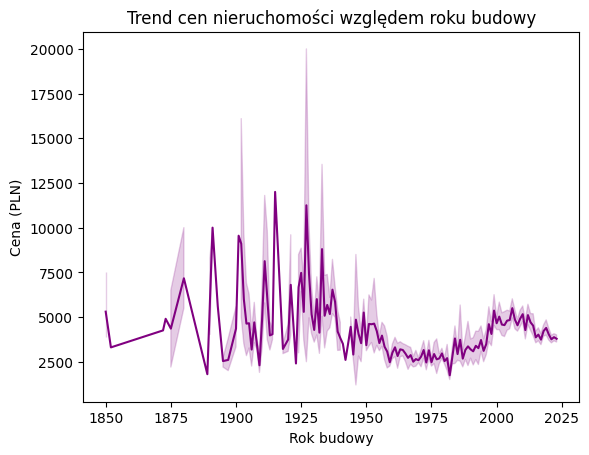

In [76]:
sns.lineplot(
    data=df_cleaned[df_cleaned['buildYear'] > 0], 
    x='buildYear', 
    y='price',
    color='purple'
)

plt.title('Trend cen nieruchomości względem roku budowy')
plt.xlabel('Rok budowy')
plt.ylabel('Cena (PLN)')
plt.show()

By zapewnić czytelność wizualizacji, z zestawu danych usunięto wartości roku budowy równe 0, ponieważ zostało to określone jako brak informacji.

**Wizualizacja z seaborn - wykres słupkowy kolorowy typ nieruchomości w danych mieście vs cena mieszkań**

<Axes: xlabel='city', ylabel='price'>

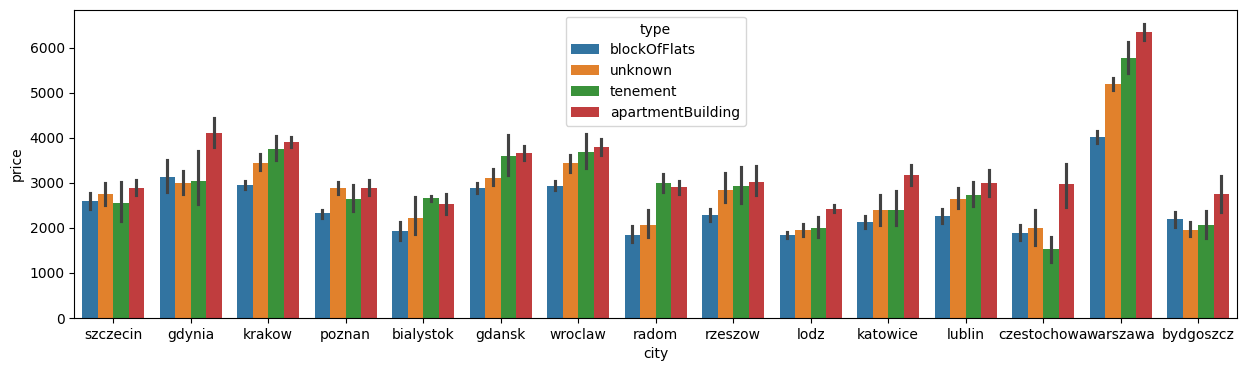

In [77]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_cleaned,
           x = "city", y = "price", hue = "type")

**Wizualizacja z seaborn - wykres pudełkowy dystans od centrum vs miasto**

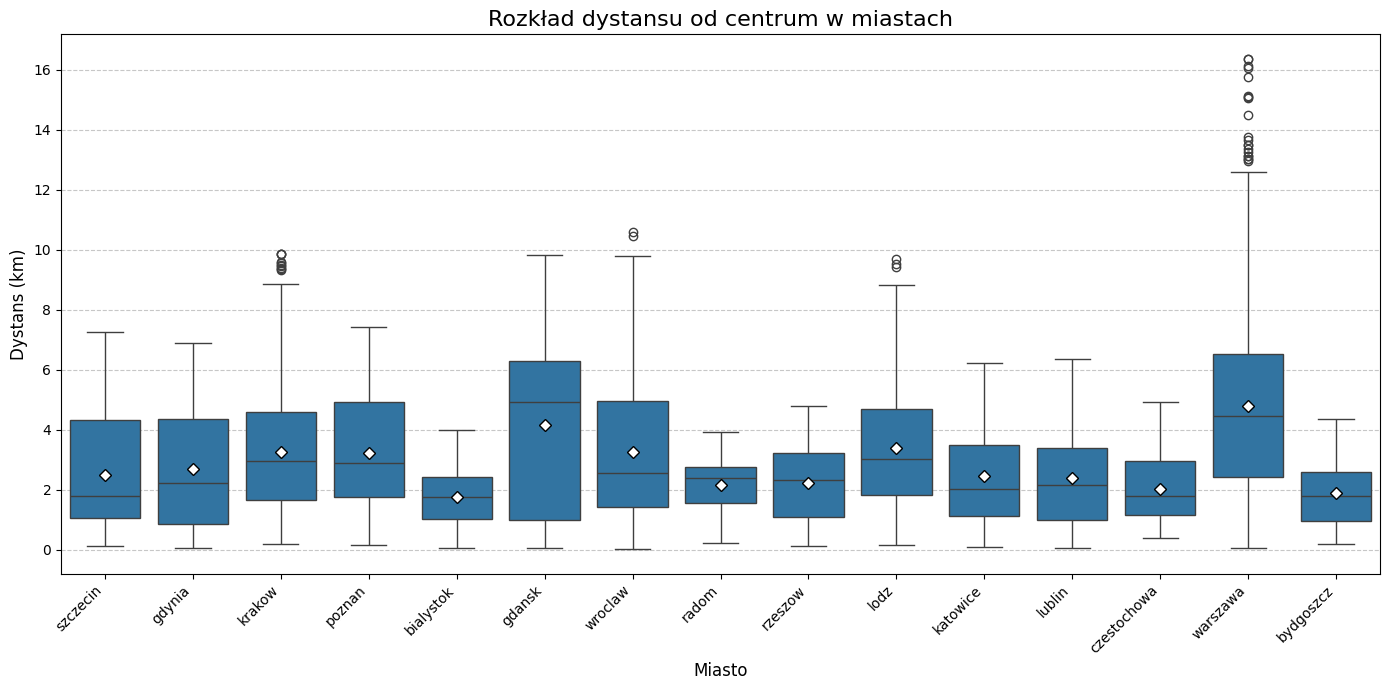

In [78]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_cleaned, x='city', y='centreDistance', showmeans=True, 
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Rozkład dystansu od centrum w miastach', fontsize=16)
plt.xlabel('Miasto', fontsize=12)
plt.ylabel('Dystans (km)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Etap 3: analiza opisowa** ##

**Skala nominalna**

In [22]:
df_cleaned["city"].value_counts()

city
warszawa       3479
krakow         1398
wroclaw         696
lodz            566
gdansk          457
poznan          399
katowice        269
szczecin        174
gdynia          174
bydgoszcz       153
lublin          135
czestochowa      79
rzeszow          63
bialystok        47
radom            33
Name: count, dtype: int64

**Statystyka opisowa danych ilorazowych**

In [23]:
df_cleaned[["price", "squareMeters",]].describe()

,price,squareMeters
count,8122.000000,8122.000000
mean,4039.576582,56.816747
std,2469.340368,23.287574
min,437.000000,25.000000
25%,2500.000000,40.000000
50%,3300.000000,50.000000
75%,4600.000000,67.000000
max,20700.000000,150.000000


**Interpretacje dla kolumny price:**  
*Mediana:* Środkowa wartość ceny nieruchomości w tym zbiorze wynosi 3300 tys. zł.  
*Średnia:* Średnia cena nieruchomości wynosi około 4039.58 tys. zł.  
*Odchylenie standardowe:* Ceny mieszkań różnią się od średniej o +/- 2469,34 tys. zł.  
*min:* Najniższa cena nieruchomości w całym zestawieniu wynosi 437 tys. zł.  
*25%:* Jedna czwarta wszystkich mieszkań w zbiorze jest dostępna w cenie do 2500 tys. zł.  
*50% (mediana):* Połowa ofert w naszym zbiorze ma cenę nieprzekraczającą 3300 tys. zł.  
*75%:* Trzy czwarte mieszkań jest oferowanych w cenie do 4600 tys. zł.  
*max:* Najdroższa nieruchomość w badanym zbiorze kosztuje 20700 tys. zł.  

**Interpretacje dla kolumny squareMeters:**  
*Mediana:* Połowa mieszkań w zbiorze ma metraż mniejszy lub równy 50 metrów kwadratowych.  
*Średnia:* Średni metraż nieruchomości wynosi około 56,82 metra kwadratowego.  
*Odchylenie standardowe:* Metraż nieruchomości wykazuje zmienność na poziomie 23,29 metra kwadratowego.  
*min:* Najmniejsza nieruchomość w całym zestawieniu ma powierzchnię 25 metrów kwadratowych.  
*25%:* Jedna czwarta dostępnych mieszkań charakteryzuje się metrażem nieprzekraczającym 40 metrów kwadratowych.  
*50% (mediana):* Połowa wszystkich mieszkań w zbiorze ma powierzchnię 50 metrów kwadratowych lub mniejszą.  
*75%:* Trzy czwarte mieszkań w bazie ma metraż równy lub mniejszy niż 67 metrów kwadratowych.  
*max:* Największa nieruchomość uwzględniona w analizie ma 150 metrów kwadratowych.  

In [65]:
srednia = df_cleaned['price'].mean()
odchylenie = df_cleaned['price'].std()
wsp_zmiennosci = (odchylenie / srednia)*100
top5 = np.percentile(df_cleaned['price'], 95)
bottom5 = np.percentile(df_cleaned['price'], 5)
print(f"Średnia: {srednia}")
print(f"Odchylenie: {odchylenie}")
print(f"Współczynnik Zmienności: {wsp_zmiennosci}")
print(f"Top 5%: {top5}")
print(f"Bottom 5%: {bottom5}")

Średnia: 4039.57658212263
Odchylenie: 2469.3403683085185
Współczynnik Zmienności: 61.128693022846036
Top 5%: 9000.0
Bottom 5%: 1800.0


**Współczynnik zmienności:** Ceny mieszkań są zróżnicowane o 61,13% względem średniej wartości, co oznacza bardzo duży rozrzut cenowy w badanym zbiorze.  
**Top 5%:** Najdroższe 5% mieszkań w ofercie kosztuje 9000,0 tys. zł  lub więcej.  
**Bottom 5%:** Najtańsze 5% mieszkań w ofercie kosztuje 1800,0 tys. zł lub mniej.  

In [33]:
ilosciowe = df_cleaned.select_dtypes(include='number')
print(markdown_summary(ilosciowe)) 

|                      |   count |     mean |      std |      min |      25% |      50% |      75% |       max |   skośność |   kurtoza |
|----------------------|---------|----------|----------|----------|----------|----------|----------|-----------|------------|-----------|
| squareMeters         |    8122 |   56.817 |   23.288 |   25     |   40     |   50     |   67     |   150     |      1.407 |     2.018 |
| rooms                |    8122 |    2.439 |    0.886 |    1     |    2     |    2     |    3     |     6     |      1.057 |     1.796 |
| floor                |    7291 |    3.477 |    2.724 |    1     |    2     |    3     |    4     |    25     |      2.143 |     6.919 |
| floorCount           |    8122 |    5.766 |    3.544 |    1     |    4     |    5     |    7     |    28     |      1.936 |     5.439 |
| buildYear            |    5777 | 1998.25  |   29.81  | 1850     | 1987     | 2010     | 2020     |  2023     |     -1.635 |     2.118 |
| latitude             |    8122 |

In [69]:
stats.pearsonr(df_cleaned['price'], df_cleaned['squareMeters'])

PearsonRResult(statistic=np.float64(0.7536264620527706), pvalue=np.float64(0.0))

Analiza korelacji Pearsona wykazała silną, dodatnią zależność między ceną a metrażem (r = 0,75), co potwierdza, że większy metraż nieruchomości wiąże się z wyższą ceną. Uzyskana wartość p-value wynosząca 0,0 świadczy o wysokiej istotności statystycznej tego wyniku.

In [68]:
from scipy.stats import skew, kurtosis
dane_ceny = df_cleaned["price"].dropna()

kurtoza_znormalizowana = kurtosis(dane_ceny)
kurtoza_surowa = kurtosis(dane_ceny, fisher=False)
print("Kurtoza znormalizowana (Excess Kurtosis):", kurtoza_znormalizowana)
print("Kurtoza surowa:", kurtoza_surowa)

Kurtoza znormalizowana (Excess Kurtosis): 8.168054768848968
Kurtoza surowa: 11.168054768848968


**Interpretacja kurtozy:** Wartość kurtozy znormalizowanej (8,17) wskazuje na silne wysmuklenie rozkładu cen i występowanie licznych wartości odstających. Kurtoza surowa (11,17) potwierdza, że rozkład ten jest dużo bardziej skupiony i posiada więcej wartości skrajnych, niż  w przypadku rozkładu normalnego. 

In [71]:
skośność_cen = skew(df_cleaned["price"].dropna())

print(f"Skośność cen mieszkań: {skośność_cen:.4f}") 

Skośność cen mieszkań: 2.4448


<Axes: xlabel='price', ylabel='Count'>

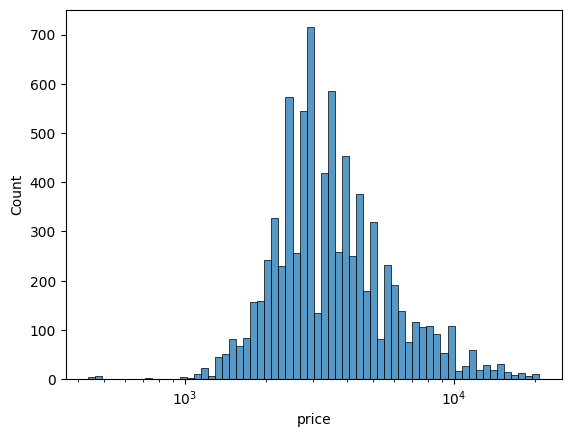

In [26]:
sns.histplot(data = df_cleaned, x = 'price', log_scale=True)

Wartość skośności wynosząca 2,44 wskazuje na silną asymetrię prawostronną rozkładu cen. Ceny nieruchomości w zbiorze nie są symetryczne, większość ofert znajduje się w niższych przedziałach cenowych, a średnia cena jest zawyżana przez nieliczne, bardzo drogie mieszkania.

In [61]:
from skimpy import skim
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 8430   │ │ float64     │ 16    │                                                          │
│ │ Number of columns │ 28     │ │ string      │ 11    │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA   ┃ NA %           ┃ mean   ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │  squareMeters   │    0 │              0 │  56.79 │  23.28 │    25 │    40 │    50 │    67 │   150 │ ▇▇▃▁▁  │  │
│ │      rooms      │    0 │              0 │  2.439 │ 0.8874 │     1 │     2 │     2 │     3 │     6 │  ▁▇▅▁  │  │
│ │      floor      │ 1030 │ 12.21826809015 │  3.468 │  2.714 │     1 │     2 │     3 │     4 │    25 │   ▇▂   │  │
│ │                 │      │           4211 │        │        │       │       │       │       │       │        │  │
│ │   floorCount    │  171 │ 2.028469750889 │  5.744 │  3.534 │     1 │     4 │     5 │     7 │    28 │  ▇▃▁   │  │
│ │                 │      │           6796 │        │        │       │       │       │       │       │        │  │
│ │    buildYear    │ 2492 │ 29.56109134045 │   1998 │  29.74 │  1850 │  1988 │  2010 │  2020 │  2023 │   ▁▁▁▇ │  │
│ │                 │      │           0773 │        │        │       │       │       │       │       │        │  │
│ │    latitude     │    0 │              0 │  51.84 │  1.195 │ 49.98 │  51.1 │ 52.19 │ 52.25 │ 54.57 │ ▃▂▇▁▁▁ │  │
│ │    longitude    │    0 │              0 │  19.74 │  1.652 │ 14.45 │ 18.66 │ 19.96 │ 21.01 │  23.2 │  ▃▂▅▇▁ │  │
│ │ centreDistance  │    0 │              0 │  3.898 │  2.648 │  0.02 │  1.74 │  3.43 │  5.53 │ 16.36 │  ▇▇▃▁  │  │
│ │    poiCount     │    0 │              0 │  25.33 │  26.93 │     0 │     9 │    17 │    31 │   210 │   ▇▁   │  │
│ │ schoolDistance  │    2 │ 0.023724792408 │ 0.3693 │ 0.3481 │ 0.002 │ 0.176 │ 0.284 │ 0.449 │ 4.856 │   ▇    │  │
│ │                 │      │          06643 │        │        │       │       │       │       │       │        │  │
│ │ clinicDistance  │    5 │ 0.059311981020 │ 0.7742 │ 0.7268 │ 0.001 │   0.3 │  0.55 │ 0.966 │ 4.875 │  ▇▂▁   │  │
│ │                 │      │          16608 │        │        │       │       │       │       │       │        │  │
│ │ postOfficeDista │    5 │ 0.059311981020 │ 0.4738 │ 0.3977 │ 0.001 │  0.24 │ 0.391 │ 0.586 │ 4.727 │   ▇▁   │  │
│ │       nce       │      │          16608 │        │        │       │       │       │       │       │        │  │
│ │ kindergartenDis │    7 │ 0.083036773428 │ 0.3313 │ 0.3344 │ 0.004 │ 0.153 │  0.26 │ 0.406 │ 4.751 │   ▇    │  │
│ │      tance      │      │           2325 │        │        │       │       │       │       │       │        │  │
│ │ restaurantDista │   24 │ 0.284697508896 │ 0.2613 │ 0.3284 │ 0.001 │ 0.086 │ 0.178 │ 0.327 │ 4.681 │   ▇    │  │
│ │       nce       │      │           7972 │        │  

**Macierz korelacji**

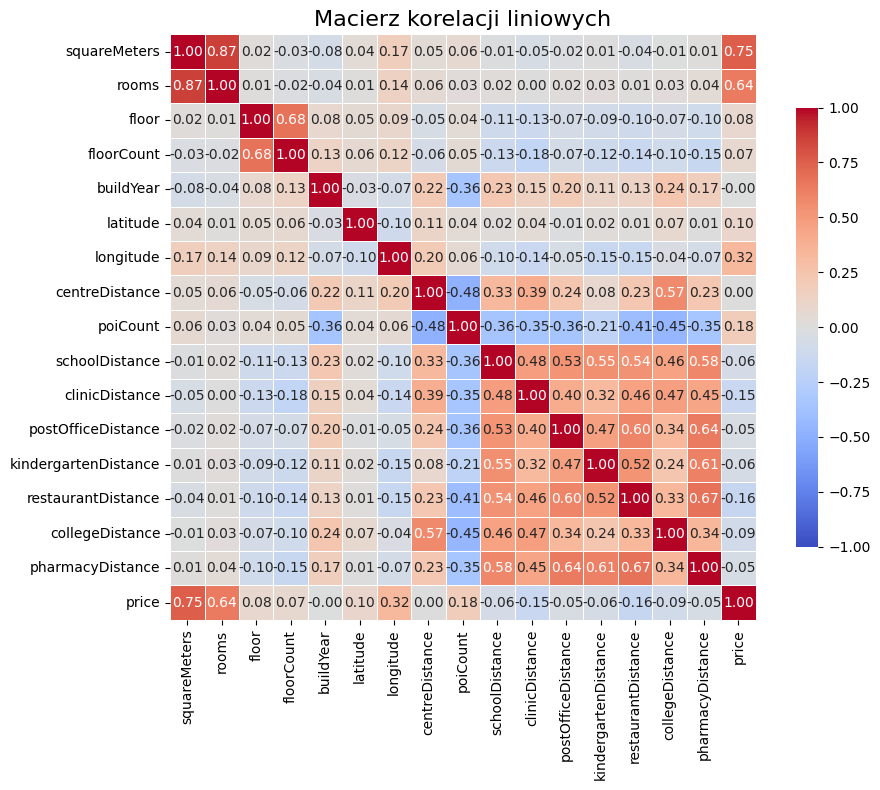

In [47]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10, 8))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f", 
 cmap="coolwarm",
 vmin=-1, vmax=1, 
 square=True, 
 linewidths=0.5, 
 cbar_kws={"shrink": .75})

plt.title("Macierz korelacji liniowych", fontsize=16)
plt.tight_layout()


plt.show()

* Najsilniejsza dodatnia korelacja występuje pomiędzy powierzchnią mieszkania a jego ceną. Wskazuje to, że wielkość nieruchomości jest kluczowym czynnikiem wpływającym na jej koszt.
* Bardzo silna zależność zachodzi również między powierzchnią a liczbą pokoi (rooms). Jest to logiczne, ponieważ większe mieszkania zazwyczaj posiadają więcej pomieszczeń.
* Z kolei zmienna floor wykazuje wysoką korelację z floorCount. Oznacza to, że mieszkania znajdujące się na wyższych piętrach zazwyczaj znajdują się w budynkach o większej liczbie kondygnacji.
* Większość zmiennych opisujących odległość od różnych punktów usługowych jest ze sobą silnie skorelowana dodatnio. Sugeruje to, że jeśli dana lokalizacja jest oddalona od danego miejsca, to najprawdopodobniej będzie również oddalona od innych miejsc.
* Zmienna poiCount wykazuje wyraźną ujemną korelację z odległościami od punktów użyteczności publicznej. Oznacza to, że w miejscach, gdzie zagęszczenie usług jest większe, dystans do nich jest odpowiednio krótszy.
* Wpływ odległości od usług na finalną cenę jest w tym zbiorze danych słaby, zatem dla kupujących najważniejszymi parametrami pozostają powierzchnia oraz liczba pokoi.